
Dataset Shape: (4756, 31)

--- First 5 Rows ---
   respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
0              1           1.0             2.0                        0.0   
1              2           1.0             1.0                        0.0   
2              3           2.0             1.0                        0.0   
3              4           0.0             1.0                        0.0   
4              5           2.0             0.0                        0.0   

   behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
0                   1.0                   0.0                    1.0   
1                   0.0                   0.0                    0.0   
2                   1.0                   0.0                    1.0   
3                   1.0                   0.0                    1.0   
4                   0.0                   0.0                    0.0   

   behavioral_large_gatherings  behavioral_outside_home

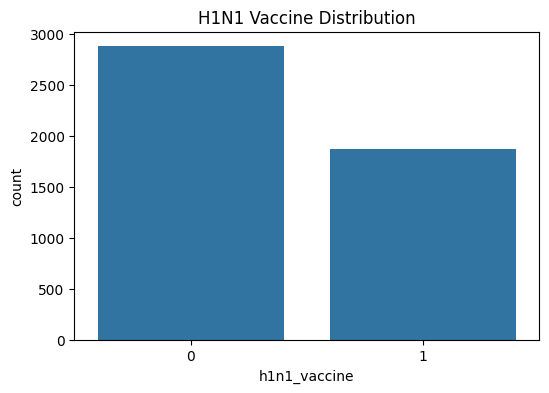


 MICE Imputation...

Accuracy: 76.26%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       577
           1       0.73      0.63      0.68       375

    accuracy                           0.76       952
   macro avg       0.75      0.74      0.74       952
weighted avg       0.76      0.76      0.76       952


Top 20 Important Features:
                        Feature  Importance
9              doctor_recc_h1n1    0.127622
15            opinion_h1n1_risk    0.099428
13             health_insurance    0.091343
28            employment_sector    0.078906
14  opinion_h1n1_vacc_effective    0.077773
17                    age_group    0.038018
21               income_poverty    0.036584
16  opinion_h1n1_sick_from_vacc    0.036139
0                  h1n1_concern    0.033993
18                    education    0.033773
25                   census_msa    0.028559
26             household_adults    0.027700
12        

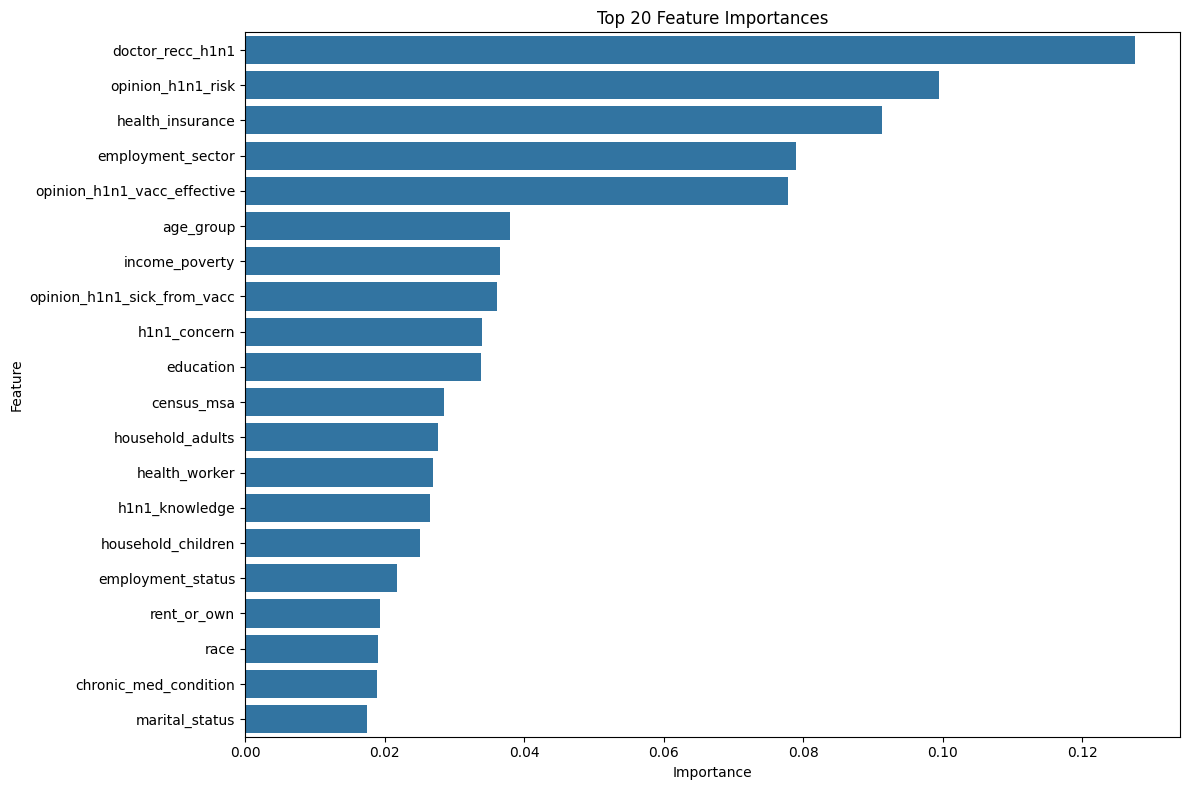


CSV file saved successfully!
File Name: h1n1_predictions.csv

First 20 Predictions:
    respondent_id  h1n1_vaccine
0            1679             1
1            2693             0
2            1898             0
3            1329             0
4            2684             0
5            3863             0
6            3219             0
7            2135             0
8            3316             1
9            3403             0
10           1777             1
11           3644             0
12           3374             0
13            646             0
14           2468             0
15           1487             0
16           2913             0
17           2627             0
18           2095             1
19           4316             1


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Imputation Libraries
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# 1. LOAD DATASET


df = pd.read_csv('dataset_B_training.csv')

print("\nDataset Shape:", df.shape)

# Save respondent_id separately
respondent_ids = df['respondent_id'].copy()


# 2. EDA


print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Target Distribution ---")
print(df['h1n1_vaccine'].value_counts())

# Target Distribution Plot
plt.figure(figsize=(6,4))
sns.countplot(x='h1n1_vaccine', data=df)
plt.title('H1N1 Vaccine Distribution')
plt.show()


# 3. PREPROCESSING


# Remove respondent_id from model features
df.drop('respondent_id', axis=1, inplace=True)

# Features and Target
X = df.drop('h1n1_vaccine', axis=1)
y = df['h1n1_vaccine']

# Label Encoding Categorical Variables
categorical_cols = X.select_dtypes(include=['object']).columns

label_encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    non_null_mask = X[col].notnull()

    X.loc[non_null_mask, col] = le.fit_transform(
        X.loc[non_null_mask, col]
    )

    label_encoders[col] = le

# Convert all columns to numeric
X = X.astype(float)

# 4. TRAIN TEST SPLIT


X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X,
    y,
    respondent_ids,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# 5. MICE IMPUTATION

print("\n MICE Imputation...")

mice_imputer = IterativeImputer(
    max_iter=10,
    random_state=42
)

X_train_imputed = pd.DataFrame(
    mice_imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test_imputed = pd.DataFrame(
    mice_imputer.transform(X_test),
    columns=X_test.columns
)

# 6. RANDOM FOREST MODEL

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_imputed, y_train)

# Predictions
y_pred = rf_model.predict(X_test_imputed)

# 7. MODEL EVALUATION

accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# 8. FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 20 Important Features:")
print(feature_importance.head(20))

plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance.head(20),
    x='Importance',
    y='Feature'
)

plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()


# 9. CREATE CSV WITH RESPONDENT ID + PREDICTION


prediction_output = pd.DataFrame({
    'respondent_id': id_test.values,
    'h1n1_vaccine': y_pred
})

prediction_output.to_csv(
    'h1n1_predictions.csv',
    index=False
)

print("\nCSV file saved successfully!")
print("File Name: h1n1_predictions.csv")

print("\nFirst 20 Predictions:")
print(prediction_output.head(20))